In [44]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
ecoli = pd.read_csv('../ncbi_562_data.csv')
salmonella = pd.read_csv('../ncbi_590_data.csv')

C:\Users\bryan\AppData\Local\Temp\ipykernel_15236\600411681.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  salmonella = pd.read_csv('../ncbi_590_data.csv')


In [45]:
ecoli = ecoli[ecoli['is_usa_based'] == 1]
ecoli['collection_year'] = pd.to_numeric(ecoli['collection_year'], errors='coerce')
ecoli = ecoli[ecoli['collection_year'] >= 2009]
ecoli = ecoli[ecoli['month'].notna()]
ecoli['collection_year'] = ecoli['collection_year'].astype(str)
ecoli['collection_year'] = ecoli['collection_year'].str[:4]
ecoli['month'] = ecoli['month'].astype(int)
ecoli['month'] = ecoli['month'].apply(lambda x: f"{x:02d}")
ecoli['year_and_month'] = ecoli['collection_year'] + '-' + ecoli['month']

salmonella = salmonella[salmonella['is_usa_based'] == 1]
salmonella['collection_year'] = pd.to_numeric(salmonella['collection_year'], errors='coerce')
salmonella = salmonella[salmonella['collection_year'] >= 2009]
salmonella = salmonella[salmonella['month'].notna()]
salmonella['collection_year'] = salmonella['collection_year'].astype(str)
salmonella['collection_year'] = salmonella['collection_year'].str[:4]
salmonella['month'] = salmonella['month'].astype(int)
salmonella['month'] = salmonella['month'].apply(lambda x: f"{x:02d}")
salmonella['year_and_month'] = salmonella['collection_year'] + '-' + salmonella['month']

In [46]:
ecoli['strain_four'] = ecoli['strain'].str[:4]
salmonella['strain_four'] = salmonella['strain'].str[:4]

In [47]:
e = ecoli['strain'].value_counts()
s = salmonella['strain'].value_counts()

In [48]:
#make a year_month_count for each of the top 10 submitters for ecoli
top_10_e_strain_4 = ecoli['strain_four'].value_counts().nlargest(10).index
ecoli_top_10 = ecoli[ecoli['strain_four'].isin(top_10_e_strain_4)]
year_month_counts_e = ecoli_top_10['year_and_month'].value_counts().sort_index()
#make a year_month
#make a year_month_count for each of the top 10 submitters for ecoli
top_10_s_strain_4 = salmonella['strain_four'].value_counts().nlargest(10).index
salmonella_top_10 = salmonella[salmonella['strain_four'].isin(top_10_s_strain_4)]
year_month_counts_s = salmonella_top_10['year_and_month'].value_counts().sort_index()

In [49]:
ecoli_top_10_counts = ecoli_top_10.groupby(['year_and_month', 'strain_four']).size().unstack(fill_value=0)
salmonella_top_10_counts = salmonella_top_10.groupby(['year_and_month', 'strain_four']).size().unstack(fill_value=0)

In [50]:
salmonella_top_10_counts

strain_four,2015,2016,ADRD,CFSA,FDA1,FDA6,FDA9,HIY0,PNUS,SAL-
year_and_month,,,,,,,,,,
2009-01,0,0,0,6,0,0,0,0,6,0
2009-02,0,0,0,0,0,0,0,0,10,0
2009-03,0,0,0,14,0,0,0,0,8,0
2009-04,0,0,0,2,0,0,0,0,8,0
2009-05,0,0,0,5,0,0,0,0,14,0
2009-06,0,0,1,47,0,0,0,0,11,0
2009-07,0,0,0,5,0,0,0,0,17,0
2009-08,0,0,2,3,0,0,0,0,29,0
2009-09,0,0,0,7,0,0,0,0,11,0


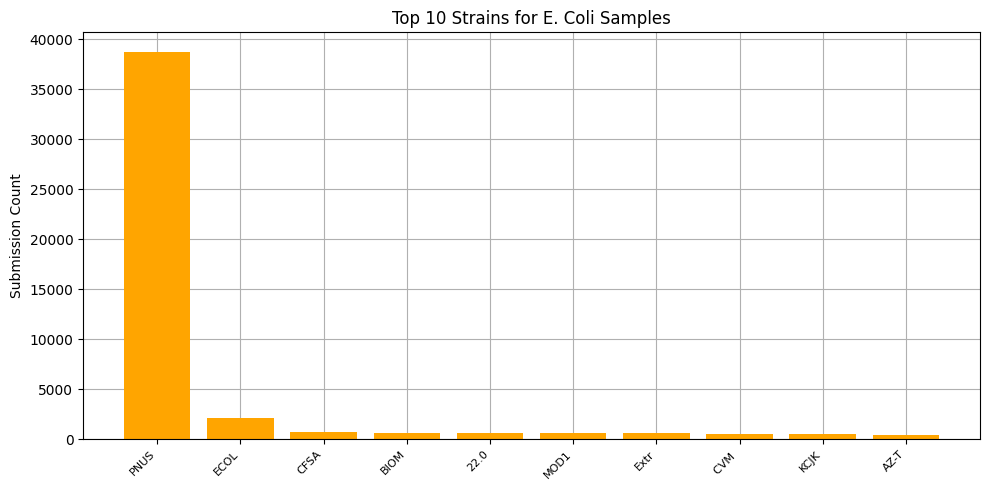

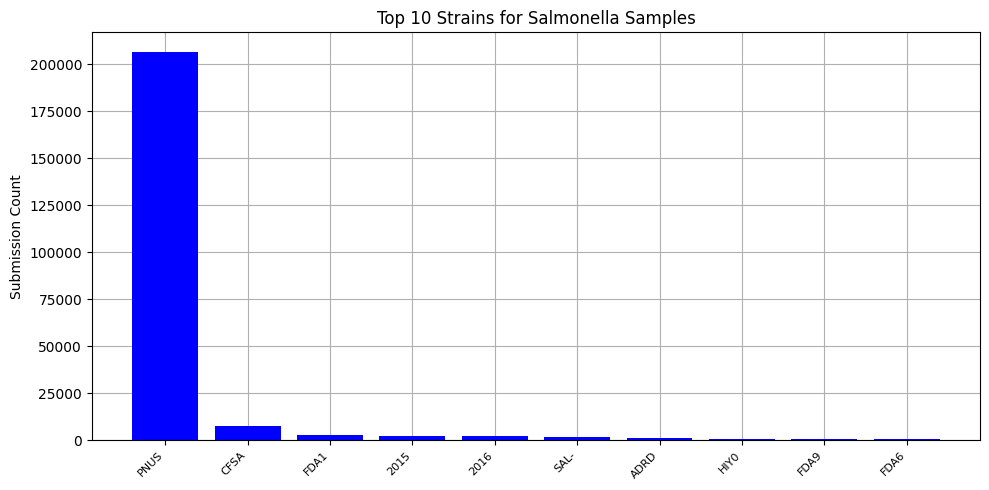

In [51]:
#make a bar chart of the top 10 submitters for each dataset
ecoli_4_10 = ecoli['strain_four'].value_counts().head(10)
salmonella_4_10 = salmonella['strain_four'].value_counts().head(10)
#make a bar chart of the top 10 strains for each dataset
plt.figure(figsize=(10, 5))
plt.bar(ecoli_4_10.index, ecoli_4_10.values, color='orange', label='E. Coli')
plt.title('Top 10 Strains for E. Coli Samples')
plt.ylabel('Submission Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.gca().set_axisbelow(True)
plt.grid(axis='both')
plt.tight_layout()
plt.savefig('../outputs/top_strains_ecoli_2009_2023.tiff', dpi=400)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(salmonella_4_10.index, salmonella_4_10.values, color='blue', label='Salmonella')
plt.title('Top 10 Strains for Salmonella Samples')
plt.ylabel('Submission Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.gca().set_axisbelow(True)
plt.grid(axis='both')
plt.tight_layout()
plt.savefig('../outputs/top_strains_salmonella_2009_2023.tiff', dpi=400)
plt.show()



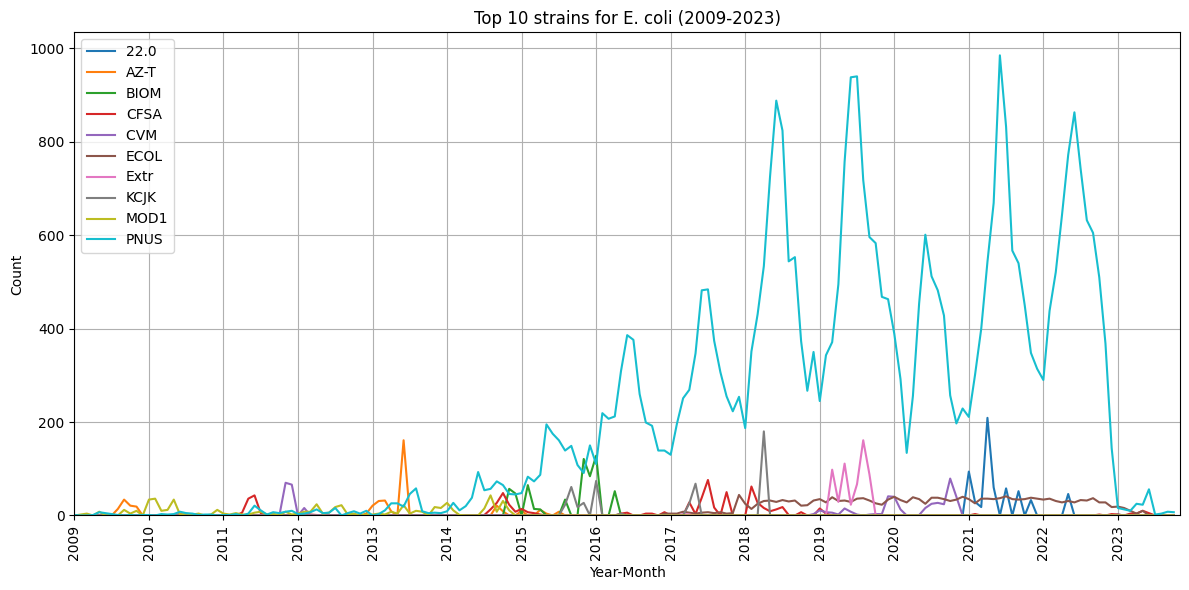

In [52]:
#make a line plot for ecoli_top_10_counts

plt.figure(figsize=(12, 6))
for strain in ecoli_top_10_counts.columns:
    plt.plot(ecoli_top_10_counts.index, ecoli_top_10_counts[strain], label=strain)
plt.xlabel('Year-Month')
plt.ylabel('Count')
plt.title('Top 10 strains for E. coli (2009-2023)')
plt.xlim(left='2009-01', right='2023-12')
plt.ylim(bottom=0)
plt.legend()
# Make the xticks only show every 12 months. Don't show the "-01" part on the ticks

plt.xticks(ticks=range(0, len(ecoli_top_10_counts.index), 12), labels=[date[:4] for date in ecoli_top_10_counts.index[::12]], rotation=90)
plt.grid(axis='both')
plt.tight_layout()
plt.savefig('../outputs/top_strains_ecoli_2009_2023_line.tiff', dpi=400)
plt.show()

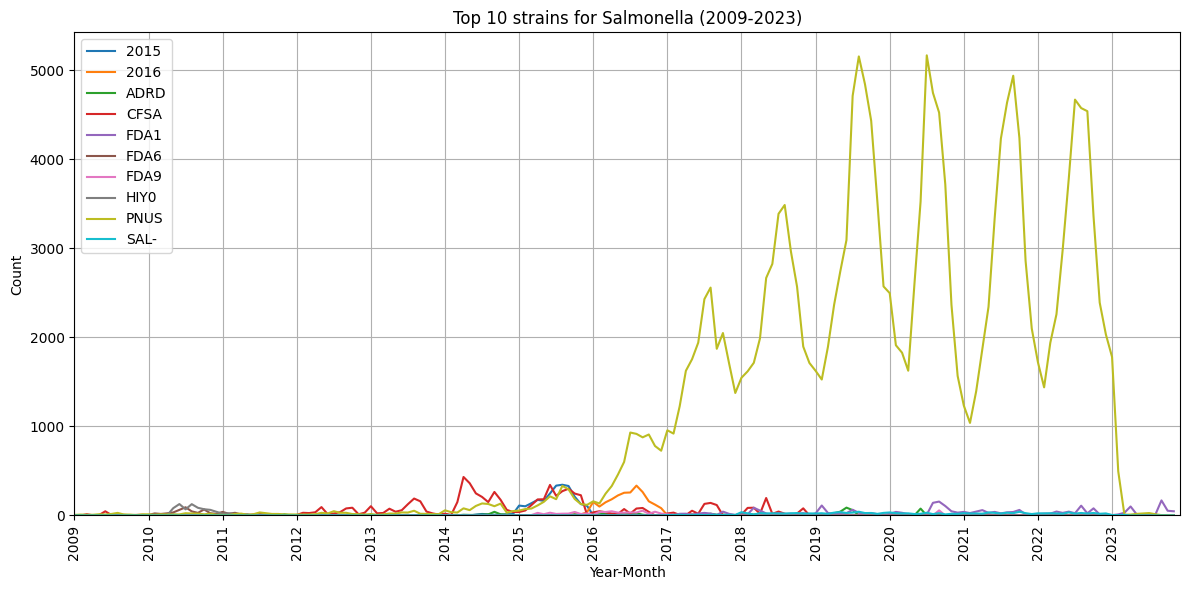

In [53]:
#make a line plot for salmonella_top_10_counts_top_10_counts

plt.figure(figsize=(12, 6))
for strain in salmonella_top_10_counts.columns:
    plt.plot(salmonella_top_10_counts.index, salmonella_top_10_counts[strain], label=strain)
plt.xlabel('Year-Month')
plt.ylabel('Count')
plt.title('Top 10 strains for Salmonella (2009-2023)')
plt.xlim(left='2009-01', right='2023-12')
plt.ylim(bottom=0)
plt.legend()
# Make the xticks only show every 12 months. Don't show the "-01" part on the ticks

plt.xticks(ticks=range(0, len(salmonella_top_10_counts.index), 12), labels=[date[:4] for date in salmonella_top_10_counts.index[::12]], rotation=90)
plt.grid(axis='both')
plt.tight_layout()
plt.savefig('../outputs/top_strains_salmonella_2009_2023_line.tiff', dpi=400)
plt.show()

In [56]:
ecoli['strain'][ecoli['strain_four'] == 'PNUS'].value_counts().sort_index(ascending=False)

strain
PNUSAU001806                     1
PNUSAS115285                     2
PNUSAS115272                     2
PNUSAS115248                     2
PNUSAS115244                     2
PNUSAS115217                     2
PNUSAS008537                     1
PNUSAS008535                     1
PNUSAS008534                     1
PNUSAS008533                     1
PNUSAS007300                     1
PNUSAE162979                     1
PNUSAE162977                     1
PNUSAE162976                     1
PNUSAE162975                     1
PNUSAE162974                     1
PNUSAE162973                     1
PNUSAE162972                     1
PNUSAE162971                     1
PNUSAE162970                     1
PNUSAE162969                     1
PNUSAE162968                     1
PNUSAE162967                     1
PNUSAE162966                     1
PNUSAE162627                     1
PNUSAE161907                     1
PNUSAE161906                     1
PNUSAE161902                     1
PNUSAE160855 

In [57]:
ecoli[ecoli['strain'] == 'PNUSAS115285'].head()

,genome,geo_loc_name,collection_date,strain,host,serotype,isolate,isolation_source,source_type,submitter,geo_loc_name_is_missing,is_usa_based,usa_state,new_isolation_source,new_host,collection_year,month,nors_primary_mode_map,year_and_month,strain_four
51612,GCA_016878815.1,USA,2019-10,PNUSAS115285,missing,NaN,missing,missing,human,Western University,False,1.0,Unknown,Missing,missing,2019,10,Indeterminate/unknown,2019-10,PNUS
112314,GCF_016878815.1,USA,2019-10,PNUSAS115285,missing,NaN,missing,missing,human,Western University,False,1.0,Unknown,Missing,missing,2019,10,Indeterminate/unknown,2019-10,PNUS


In [ ]:
ecoli['common_abbreviation'] = ecoli['strain_four'].copy()
ecoli.loc[ecoli['strain_four'] == 'PNUS', 'common_abbreviation'] = 'PNUSA'
ecoli.loc[ecoli['strain_four'] == 'ECOL', 'common_abbreviation'] = 'ECOLI'
ecoli.loc[ecoli['strain_four'] == 'FDA1', 'common_abbreviation'] = 'FDA'
ecoli.loc[ecoli['strain_four'] == 'FDA9', 'common_abbreviation'] = 'FDA'
ecoli.loc[ecoli['strain_four'] == 'FDA6', 'common_abbreviation'] = 'FDA'
ecoli.loc[ecoli['strain_four'] == 'CFSA', 'common_abbreviation'] = 'CFSAN'
ecoli.loc[ecoli['strain_four'] == 'FDA6', 'common_abbreviation'] = 'FDA'
ecoli.loc[ecoli['strain_four'] == 'FDA6', 'common_abbreviation'] = 'FDA'
ecoli.loc[ecoli['strain_four'] == 'FDA6', 'common_abbreviation'] = 'FDA'
